# Energy Consumption Forecasting with Hyperparameter Tuning
This notebook includes:
- Data loading
- Preprocessing
- Feature engineering
- Pair plot, box plot
- Outlier detection and removal
- Correlation analysis
- Train/test split
- Scaling
- GridSearchCV (cv=3, n_jobs=20)
- Multiple regression models
- Model comparison
- Feature importance using XGBoost

In [ ]:
# Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor

from xgboost import XGBRegressor

In [2]:
# Load dataset
df = pd.read_csv('powerconsumption.csv')
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
# Convert Datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

In [4]:
# Feature Engineering
df['Hour'] = df['Datetime'].dt.hour
df['Day'] = df['Datetime'].dt.day
df['Month'] = df['Datetime'].dt.month
df['DayOfWeek'] = df['Datetime'].dt.dayofweek

# Remove unused zones
df = df.drop(columns=['Datetime','PowerConsumption_Zone2','PowerConsumption_Zone3'])

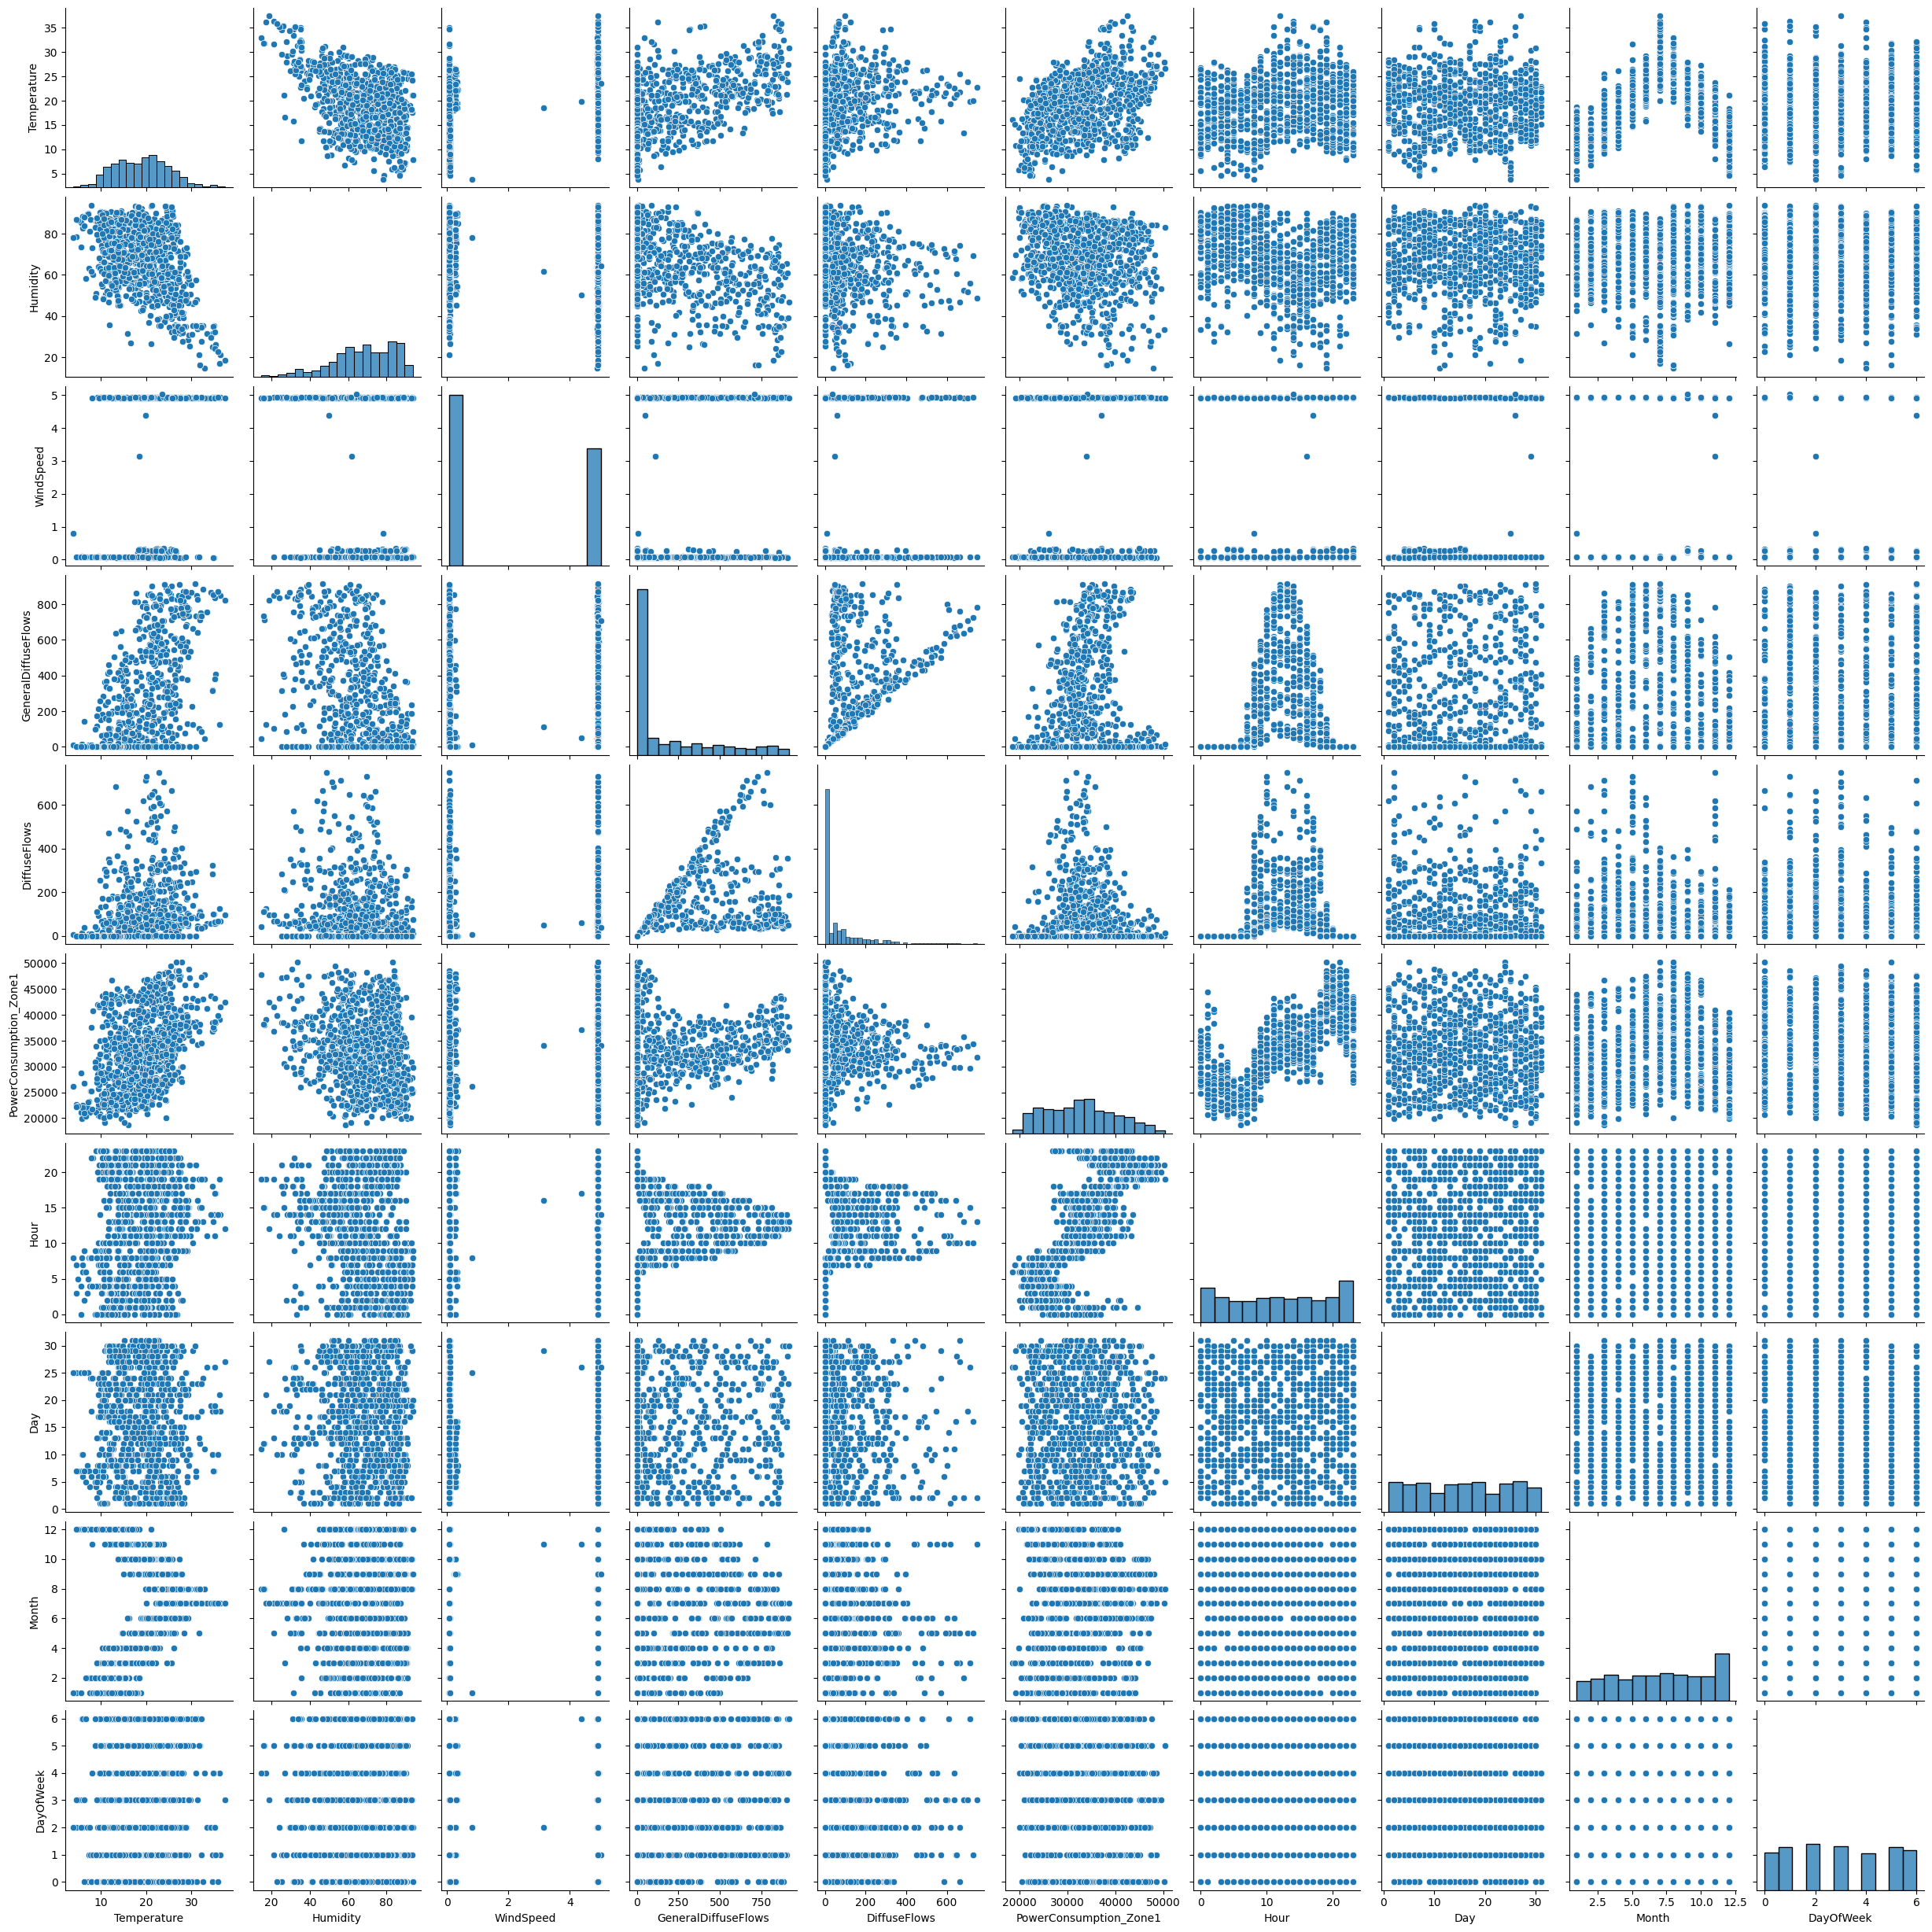

In [5]:
# Pair plot
sns.pairplot(df.sample(1000))

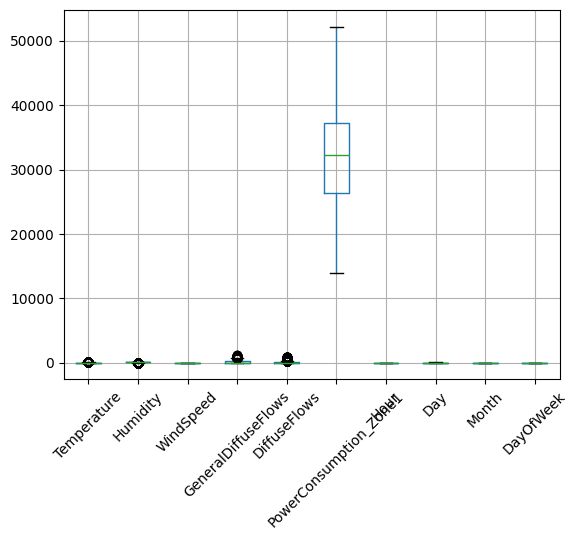

In [6]:
# Box plot for outlier detection
plt.figure()
df.boxplot(rot=45)
plt.show()

In [7]:
# Outlier detection using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print('Original:', df.shape)
print('After outlier removal:', df_clean.shape)

Original: (52416, 10)
After outlier removal: (45492, 10)


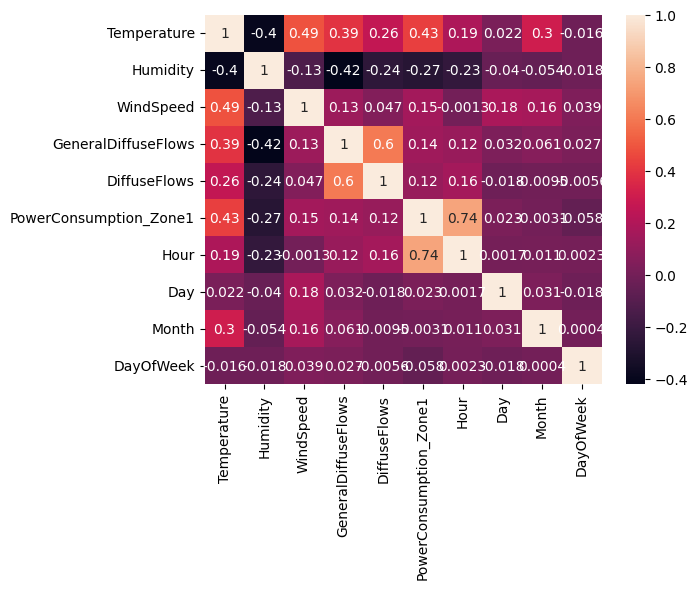

In [8]:
# Correlation heatmap
plt.figure()
sns.heatmap(df_clean.corr(), annot=True)
plt.show()

In [9]:
# Feature selection
y = df_clean['PowerConsumption_Zone1']
X = df_clean.drop(columns=['PowerConsumption_Zone1'])

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## GridSearchCV Models (cv=3, n_jobs=20)

In [12]:
# Linear Regression
lr_params = {
    'fit_intercept':[True,False],
    'positive':[True,False],
    'copy_X':[True,False]
}

grid_lr = GridSearchCV(
    LinearRegression(),
    lr_params,
    cv=3,
    n_jobs=20
)
print("Linear Regression")

grid_lr.fit(X_train,y_train)
print("DONE")

Linear Regression
DONE


In [13]:
# AdaBoost
ada_params = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,1],
    'loss':['linear','square']
}

grid_ada = GridSearchCV(
    AdaBoostRegressor(),
    ada_params,
    cv=3,
    n_jobs=20
)
print("ADA Boost")

grid_ada.fit(X_train,y_train)
print("DONE")

ADA Boost
DONE


In [14]:
# Gradient Boosting
gb_params = {
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5],
    'min_samples_split':[2,5]
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(),
    gb_params,
    cv=3,
    n_jobs=20
)
print("GD Boosting")
grid_gb.fit(X_train,y_train)
print("DONE")

GD Boosting
DONE


In [15]:
# Random Forest
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5],
    'max_features':['sqrt','log2']
}

grid_rf = GridSearchCV(
    RandomForestRegressor(),
    rf_params,
    cv=3,
    n_jobs=20
)
print("RANDOM FORREST")

grid_rf.fit(X_train,y_train)
print("DONE")


RANDOM FORREST
DONE


In [16]:
# XGBoost
xgb_params = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1],
    'min_child_weight':[1,3,5],
    'subsample':[0.8,1]
}

grid_xgb = GridSearchCV(
    XGBRegressor(objective='reg:squarederror'),
    xgb_params,
    cv=3,
    n_jobs=20
)
print("XGBoost")

grid_xgb.fit(X_train,y_train)
print("DONE")

XGBoost
DONE


In [17]:
# Evaluation function
def evaluate(model,name):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test,preds)
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    r2 = r2_score(y_test,preds)
    return [name,mae,rmse,r2]

In [18]:
# Evaluate models
results = []
results.append(evaluate(grid_lr,'Linear Regression'))
results.append(evaluate(grid_ada,'AdaBoost'))
results.append(evaluate(grid_gb,'Gradient Boosting'))
results.append(evaluate(grid_rf,'Random Forest'))
results.append(evaluate(grid_xgb,'XGBoost'))

results_df = pd.DataFrame(results,columns=['Model','MAE','RMSE','R2'])
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,3457.949361,4349.305261,0.657284
1,AdaBoost,2428.751581,3036.983792,0.832899
2,Gradient Boosting,916.609060,1267.300579,0.970903
3,Random Forest,691.058738,1013.210548,0.981401
4,XGBoost,718.766098,1014.061173,0.981370


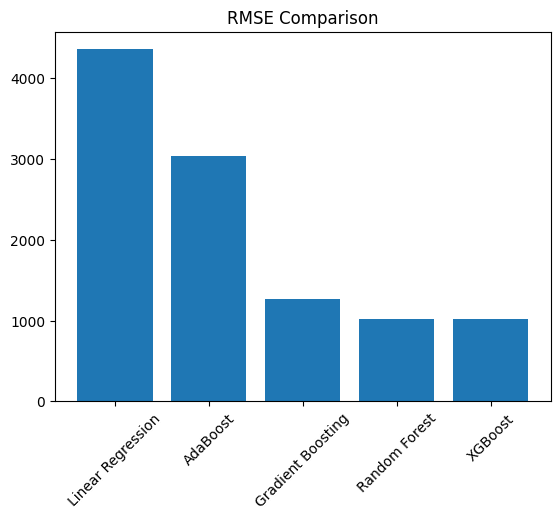

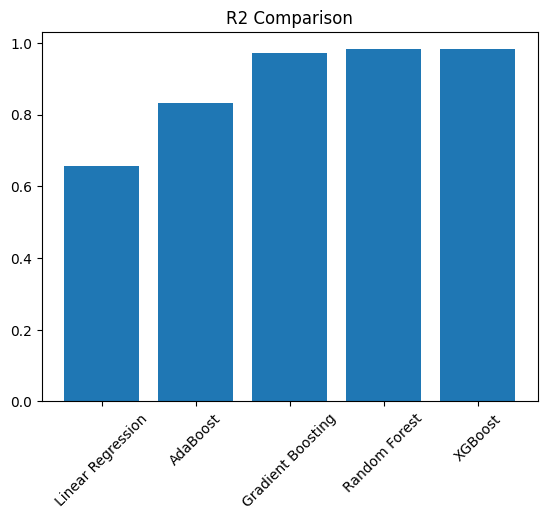

In [19]:
# RMSE comparison plot
plt.figure()
plt.bar(results_df['Model'],results_df['RMSE'])
plt.xticks(rotation=45)
plt.title('RMSE Comparison')
plt.show()

# R2 comparison plot
plt.figure()
plt.bar(results_df['Model'],results_df['R2'])
plt.xticks(rotation=45)
plt.title('R2 Comparison')
plt.show()

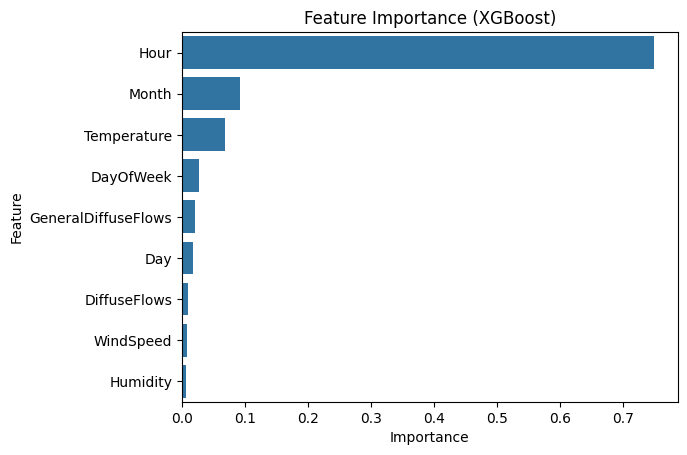

In [20]:
# Feature importance from best XGBoost
best_xgb = grid_xgb.best_estimator_
importances = best_xgb.feature_importances_

importance_df = pd.DataFrame({
    'Feature':X.columns,
    'Importance':importances
}).sort_values(by='Importance',ascending=False)

plt.figure()
sns.barplot(x='Importance',y='Feature',data=importance_df)
plt.title('Feature Importance (XGBoost)')
plt.show()